In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import xgboost as xgb
from sklearn.metrics import confusion_matrix
from math import pi
import plotly.graph_objects as go

In [2]:
df = pd.read_csv(os.path.join("..", "data", "processed", "training_data_with_clusters.csv"))

df.head()

,driver_id,signup_date,avg_rating,current_tier,Churned,avg_earnings_per_hour_online,trip_utilization_rate,surge_reliance_score,is_premium_capable,premium_trip_ratio,peak_hour_driver_score,session_regularity,quest_completion_rate,incentive_reliance_pct,pro_tier_status,cancellation_rate,acceptance_rate,cluster_label
0,5729981b-bf65-48ac-a418-95693a8d26ef,2025-07-16 08:43:42.076226-04:00,4.84,Blue,0,12.716965,0.429709,0.078188,0,0.000000,0.481818,89.034310,0.000000,0.000000,3,0.130137,0.666667,0
1,caf9988b-9ff9-4dcc-b9a5-4d6953ac8a0b,2025-11-04 02:36:10.076226-05:00,4.80,Platinum,0,17.065534,0.525368,0.102074,0,0.000000,0.476112,3.705339,0.875000,0.115524,1,0.102744,0.851168,3
2,5d9761b2-ee05-4923-98ca-1f16a4a6df73,2025-06-27 03:06:08.076226-04:00,4.91,Diamond,0,31.851693,0.419952,0.150102,1,0.806924,0.439414,30.094497,0.166667,0.005854,0,0.022485,0.497644,2
3,0a298bab-317f-49f7-a021-432c6cf80366,2025-10-18 22:08:13.076226-04:00,4.94,Platinum,0,31.627454,0.400830,0.183966,1,0.798283,0.419170,9.303206,0.166667,0.004039,1,0.014570,0.495407,2
4,5843b2fc-ffa0-4cd2-a0bc-c950eecab4f0,2025-08-14 01:17:21.076226-04:00,4.72,Blue,1,12.421348,0.400394,0.125967,0,0.000000,0.414894,57.364287,0.000000,0.000000,3,0.170732,0.584323,0


In [3]:
print(f"Dimensions: {df.shape}")
print(f"Cluster Sizes:\n{df['cluster_label'].value_counts().sort_index()}")

Dimensions: (581, 18)
Cluster Sizes:
cluster_label
0    194
1    107
2     96
3    184
Name: count, dtype: int64


In [4]:
cluster_features = [
    'avg_earnings_per_hour_online',
    'trip_utilization_rate',
    'surge_reliance_score',
    'premium_trip_ratio',
    'quest_completion_rate',
    'cancellation_rate'
]

In [5]:
cluster_means = df.groupby('cluster_label')[cluster_features].mean()

In [6]:
scaler_min = df[cluster_features].min()
scaler_max = df[cluster_features].max()
normalized_means = (cluster_means - scaler_min) / (scaler_max - scaler_min)

In [7]:
df_melted = normalized_means.reset_index().melt(id_vars='cluster_label')
df_melted.columns = ['Cluster', 'Attribute', 'Normalized Value']

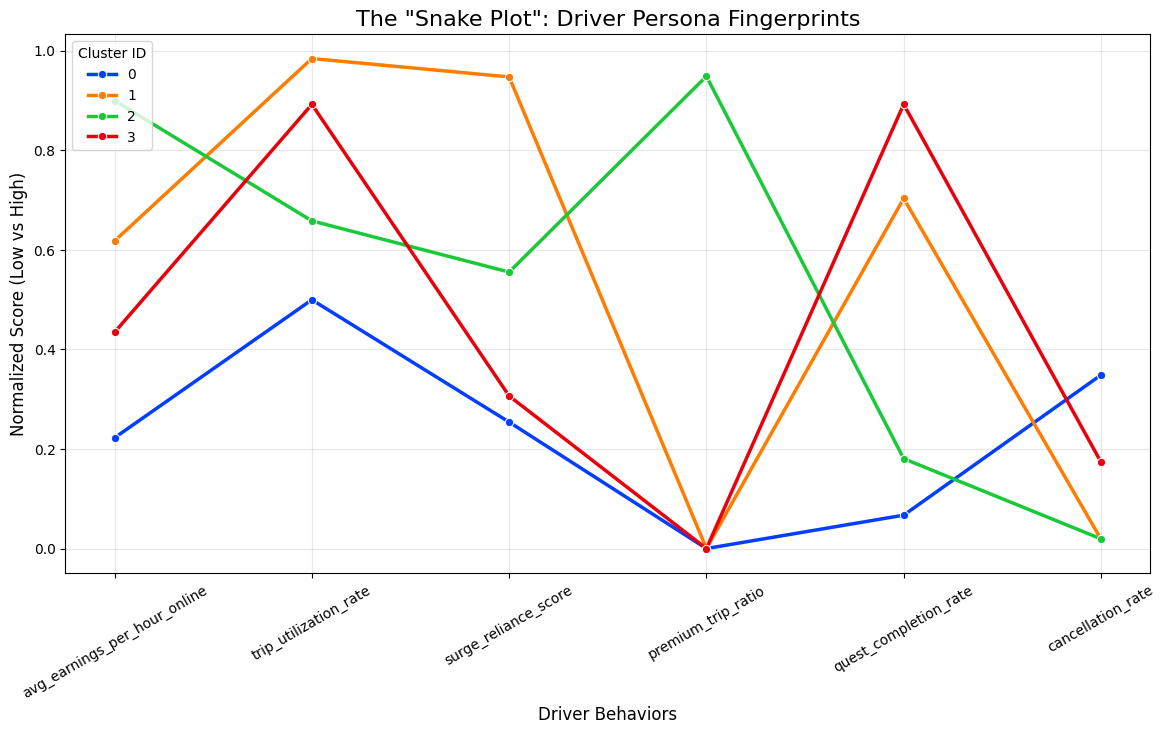

In [8]:
# --- PLOTTING ---
plt.figure(figsize=(14, 7))

# Draw the lines
sns.lineplot(
    data=df_melted, 
    x='Attribute', 
    y='Normalized Value', 
    hue='Cluster', 
    palette='bright', 
    marker='o', 
    linewidth=2.5
)

plt.title('The "Snake Plot": Driver Persona Fingerprints', fontsize=16)
plt.ylabel('Normalized Score (Low vs High)', fontsize=12)
plt.xlabel('Driver Behaviors', fontsize=12)
plt.xticks(rotation=30)
plt.legend(title='Cluster ID', loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

C:\Users\burha\AppData\Local\Temp\ipykernel_68056\191086143.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\burha\AppData\Local\Temp\ipykernel_68056\191086143.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


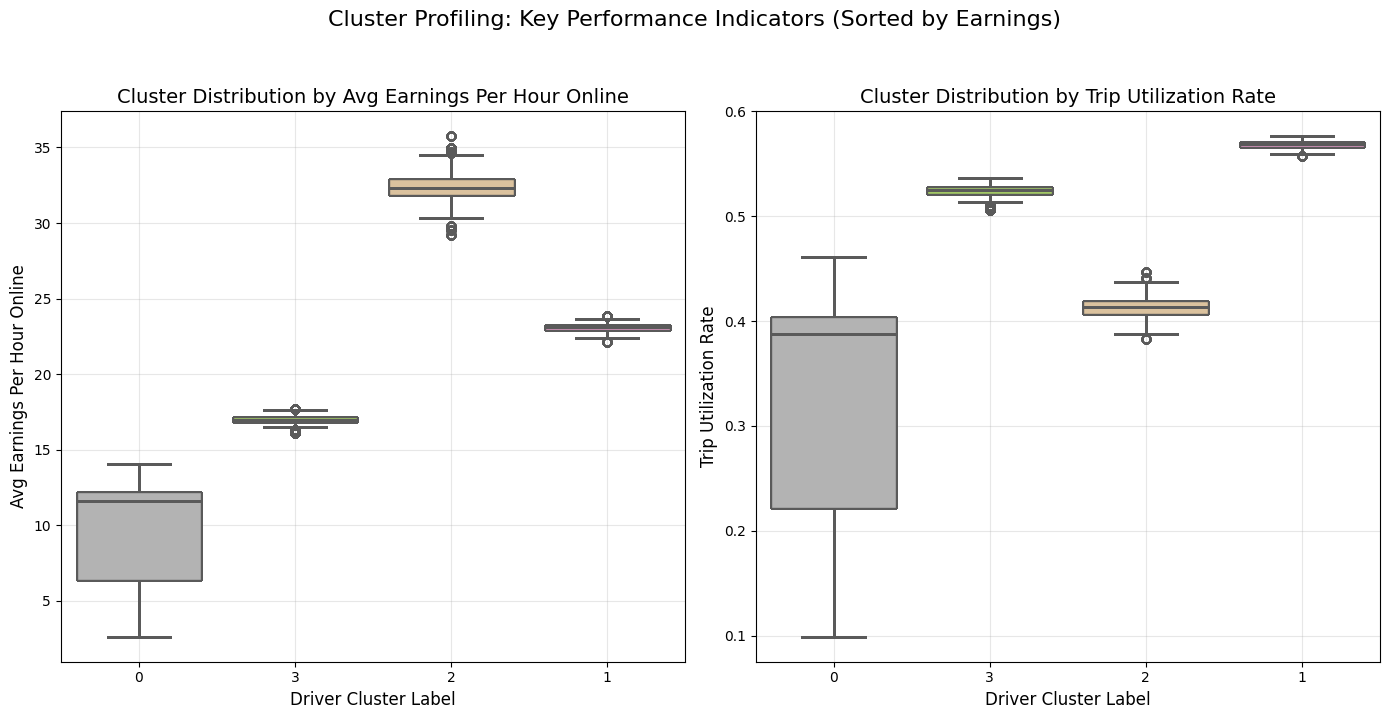

In [9]:
# The optimized code:
features_to_check = ['avg_earnings_per_hour_online', 'trip_utilization_rate']

# 1. Increased figure size for better vertical space
plt.figure(figsize=(14, 7))

for i, col in enumerate(features_to_check):
    # 2. Used (1, 2) layout for two plots
    plt.subplot(1, 2, i+1)
    sns.boxplot(
        x='cluster_label',
        y=col,
        data=df,
        palette='Set2',
        order=df.cluster_label # Apply the sorted order
    )
    plt.title(f'Cluster Distribution by {col.replace("_", " ").title()}', fontsize=14)
    plt.xlabel('Driver Cluster Label', fontsize=12)
    plt.ylabel(col.replace('_', ' ').title(), fontsize=12)
    plt.grid(True, alpha=0.3)

plt.suptitle('Cluster Profiling: Key Performance Indicators (Sorted by Earnings)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [10]:
os.path.join("..", "data", "processed", "training_data_with_clusters.csv")

'..\\data\\processed\\training_data_with_clusters.csv'

Churn Model Loaded.


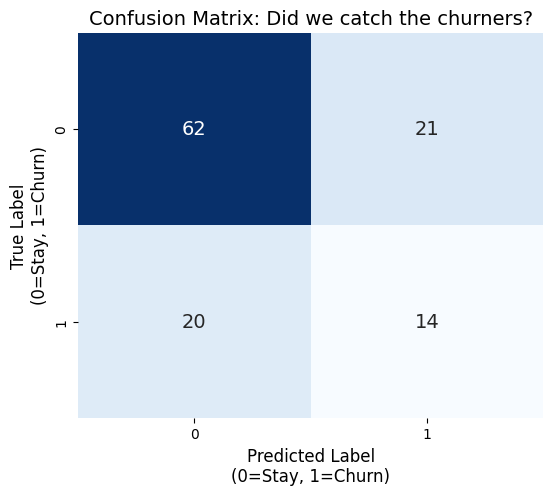

In [11]:
# 1. Load the Saved Churn Model
# Note: XGBoost models save as JSON, but we need to reconstruct the object
churn_model = xgb.XGBClassifier()
churn_model.load_model(os.path.join("..","models", "churn_model.json"))

print("Churn Model Loaded.")

# 2. Prepare the Test Data (Re-creating the split exactly as we did in training)
# We need to do this to get the X_test and y_test data again
from sklearn.model_selection import train_test_split

# Prepare Feature Matrix X and Target y
# We must cast cluster_label to category again
df['cluster_label'] = df['cluster_label'].astype('category')

features_for_model = [
    'avg_earnings_per_hour_online', 'trip_utilization_rate', 'surge_reliance_score',
    'premium_trip_ratio', 'quest_completion_rate', 'cancellation_rate',
    'acceptance_rate', 'pro_tier_status', 'cluster_label'
]

X = df[features_for_model]
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Predict
y_pred = churn_model.predict(X_test)

# 4. Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 14})
plt.xlabel('Predicted Label\n(0=Stay, 1=Churn)', fontsize=12)
plt.ylabel('True Label\n(0=Stay, 1=Churn)', fontsize=12)
plt.title('Confusion Matrix: Did we catch the churners?', fontsize=14)
plt.show()

C:\Users\burha\AppData\Local\Temp\ipykernel_68056\3830726914.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


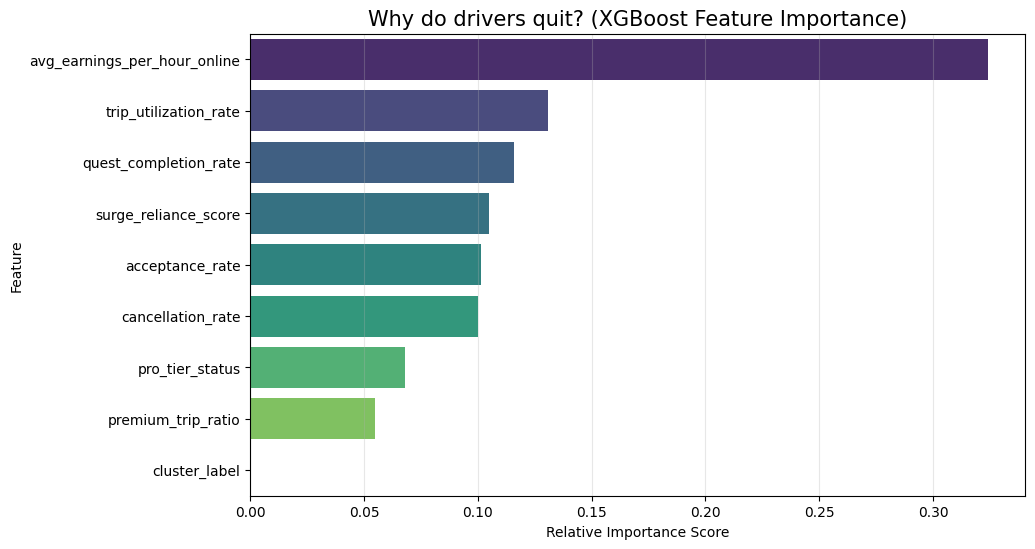

In [12]:
# Get feature importance from the model
importance = churn_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for plotting
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Why do drivers quit? (XGBoost Feature Importance)', fontsize=15)
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.show()

C:\Users\burha\AppData\Local\Temp\ipykernel_68056\1402346312.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby('Persona')['Churned'].mean().reset_index().sort_values(by='Churned', ascending=False)
C:\Users\burha\AppData\Local\Temp\ipykernel_68056\1402346312.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Persona', y='Churned', data=churn_rate, palette='Reds_r')


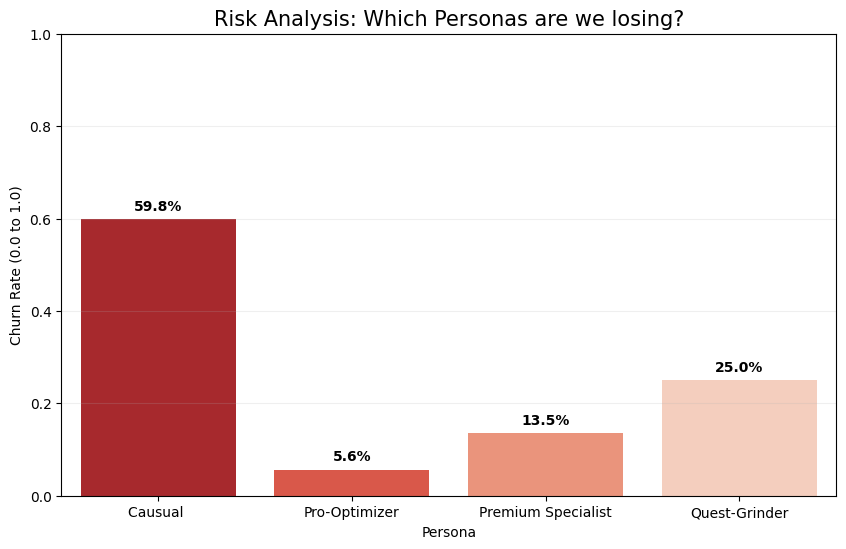

In [13]:
# Map the labels to names for a better chart
cluster_names = {
    0: "Causual ",
    1: "Pro-Optimizer",
    2: "Premium Specialist",
    3: "Quest-Grinder"
}

df['Persona'] = df['cluster_label'].map(cluster_names)

# Calculate Churn Rate per Persona
churn_rate = df.groupby('Persona')['Churned'].mean().reset_index().sort_values(by='Churned', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Persona', y='Churned', data=churn_rate, palette='Reds_r')
plt.title('Risk Analysis: Which Personas are we losing?', fontsize=15)
plt.ylabel('Churn Rate (0.0 to 1.0)')
plt.ylim(0, 1)

# Add percentage labels
for index, row in churn_rate.iterrows():
    plt.text(index, row.Churned + 0.02, f"{row.Churned:.1%}", color='black', ha="center", fontweight='bold')

plt.grid(axis='y', alpha=0.2)
plt.show()

In [ ]:
# Select Operational Metrics
metrics = [
    'acceptance_rate',
    'trip_utilization_rate',
    'surge_reliance_score',
    'quest_completion_rate',
    'cancellation_rate',
    'avg_earnings_per_hour_online'
]

# Friendly Label Names for the Chart
metric_labels = [
    'Acceptance Rate', 'Trip Utilization', 'Surge Reliance', 
    'Quest Completion', 'Cancellation Rate', 'Avg Earnings/Hr'
]

# Normalize Data (Min-Max Scaling to 0-1 range)
cluster_means = df.groupby('cluster_label')[metrics].mean()
min_vals = df[metrics].min()
max_vals = df[metrics].max()
normalized_means = (cluster_means - min_vals) / (max_vals - min_vals)

# Define Persona Names & Refined Colors (Better Contrast)
persona_names = {
    0: "Casual Driver",
    1: "Pro-Optimizer",
    2: "Premium Specialist",
    3: "Quest Grinder"
}

# Updated Palette: Using hex codes for high distinction
colors = [
    '#708090', # Slate Grey (Casual - Neutral)
    '#FFAE00', # Amber/Gold (Pro - High Value)
    '#9B59B6', # Amethyst (Premium - Luxury)
    '#E74C3C'  # Red (Grinder - High Intensity)
]

# 3. BUILD THE PLOTLY CHART
# ---------------------------------------------------------
fig = go.Figure()

# Loop through each persona and add a trace
for i in range(4):
    # Get values and close the loop
    r_values = normalized_means.loc[i].values.tolist()
    r_values += r_values[:1]
    
    theta_values = metric_labels
    theta_values += theta_values[:1]
    
    fig.add_trace(go.Scatterpolar(
        r=r_values,
        theta=theta_values,
        fill='toself',
        name=persona_names[i],
        mode='lines+markers', # Add markers to define points clearly
        marker=dict(size=6),
        line=dict(color=colors[i], width=3), # Thicker line for better definition
        opacity=0.8, # Line opacity
        fillcolor=colors[i], # Use the same color for fill...
        # We handle fill opacity by adjusting the layout/trace rendering order implicitly 
        # or we can use rgba colors, but Plotly's default fill often handles this well.
        # To be safe for "blending", we can rely on the line definition.
    ))

# 4. FINALIZE DESIGN
# ---------------------------------------------------------
fig.update_layout(
    title={
        'text': "<b>Driver Persona Fingerprints</b><br><sub>(Operational Metrics Comparison)</sub>",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1], # FORCES the 0 to 100% scale
            tickvals=[0.2, 0.4, 0.6, 0.8, 1.0], # Explicit ticks including 100%
            ticktext=['20%', '40%', '60%', '80%', '100%'], # Friendly labels
            showticklabels=True, 
            gridcolor="#E0E0E0", # Subtle grid
            linecolor="black", # Stronger axis line
            linewidth=1
        ),
        angularaxis=dict(
            tickfont=dict(size=12, color="#333333", family="Arial, sans-serif"),
            linecolor="black", # Add an outer boundary line
            linewidth=2
        ),
        bgcolor="white"
    ),
    legend=dict(
        title="Driver Segments",
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.05,
        font=dict(size=12)
    ),
    margin=dict(t=80, b=50, l=80, r=80),
    width=950,
    height=750
)

# 5. DISPLAY
# ---------------------------------------------------------
# Apply opacity to fills manually after creation for perfect control
# (Plotly allows updating traces in bulk)
fig.update_traces(opacity=0.7, selector=dict(type='scatterpolar')) 
# Note: 'opacity' here affects the whole trace. 
# For distinct fills without muddying, plotting lighter fills manually is complex in simple scripts.
# The best fix is usually lower opacity on the trace itself.

fig.show()

C:\Users\burha\AppData\Local\Temp\ipykernel_68056\4081411628.py:18: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

